In [57]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.galdist import galaxy_distribution

from itertools import product
from copy      import deepcopy
from time      import time

from scipy.interpolate import interp1d
from scipy.integrate   import trapz

import warnings
warnings.filterwarnings('ignore')

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

In [58]:
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'tau': 0.05,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'A_IA': 1.72,
            'eta_IA': -0.41}
nuis_keys  = ['A_IA','eta_IA','b0_poly','b1_poly','b2_poly','b3_poly']
cosmo_keys = [key for key in fiducial.keys() if key not in nuis_keys]

In [59]:
dist = galaxy_distribution(survey='Euclid-10')
bin_lims = dist.galdict['bin_lims']
bin_mids = 0.5*(bin_lims[:-1]+bin_lims[1:])
Nbins_wl = len(bin_lims)-1
distributions = {}
distributions['WL'] = {'dist': dist.galdict['binned_dist'],
                       'Nbins': Nbins_wl,
                       'zmean': bin_mids}

In [60]:

import camb

kmax  = 50
zcamb = np.linspace(0.001,4,100)

cosmo_params = {key:par for key,par in fiducial.items() if key not in nuis_keys}

pars    = camb.set_params(**cosmo_params)
pars.set_matter_power(redshifts=zcamb, kmax=2.0)

results   = camb.get_results(pars)
Pk_interp = camb.get_matter_power_interpolator(pars, nonlinear=True, 
                                               hubble_units=False, k_hunit=False, kmax=kmax,
                                               var1='delta_tot',var2='delta_tot', zmax=zcamb[-1])


Note: redshifts have been re-sorted (earliest first)


In [61]:
zinterps = np.logspace(-3,np.log10(4),500)
zinterp=np.linspace(0.001,3,500)
z0 = 0.001
ks = 0.001
P_z_k = Pk_interp.P(zinterps, ks)
Dz    = np.sqrt(P_z_k / Pk_interp.P(z0, ks))

Om = results.get_Omega('cdm')+results.get_Omega('baryon')+results.get_Omega('nu')

cosmo_dict = {'cosmo_params': {k:v for k,v in fiducial.items() if k in cosmo_keys}}


IA = -fiducial['A_IA']*0.0134*Om*(1+zinterps)**fiducial['eta_IA']/Dz
#print(IA)
cosmo_dict['IA_term']= interp1d(zinterps,IA)
IA_binned = cosmo_dict['IA_term'](zinterp)
print(len(distributions['WL']['zmean']))

10


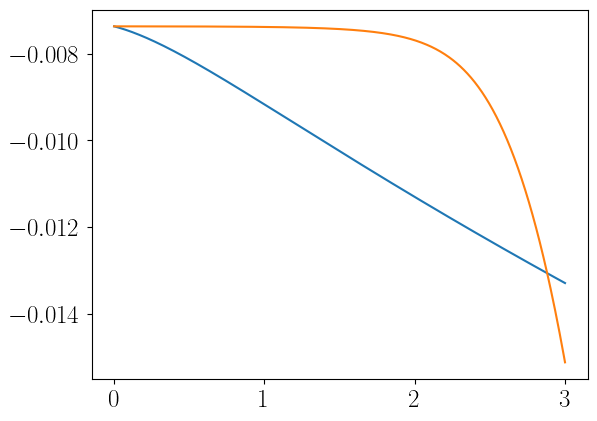

In [33]:

plt.plot(zinterp, IA)
plt.show()

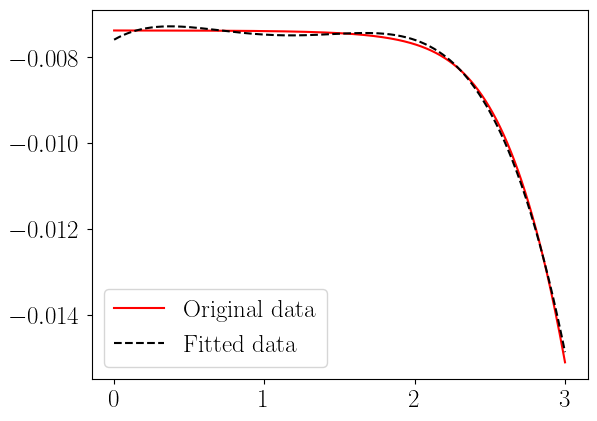

Chi-square: 3.129848509109107e-06
            4            3            2
-0.0006784 x + 0.002918 x - 0.004127 x + 0.002008 x - 0.007589


In [55]:
degree = 4
coefficients = np.polyfit(zinterp,IA,degree)
poly_func = np.poly1d(coefficients)
IA_fitted = poly_func(zinterp)
plt.plot(zinterp, IA, '-', label='Original data', color='red')
plt.plot(zinterp, IA_fitted, '--', label='Fitted data', color='black')
plt.legend()
plt.show()
residuals = IA - IA_fitted

# Calculate chi-square
chi2 = np.sum((residuals)**2)
print(f"Chi-square: {chi2}")

print(poly_func)

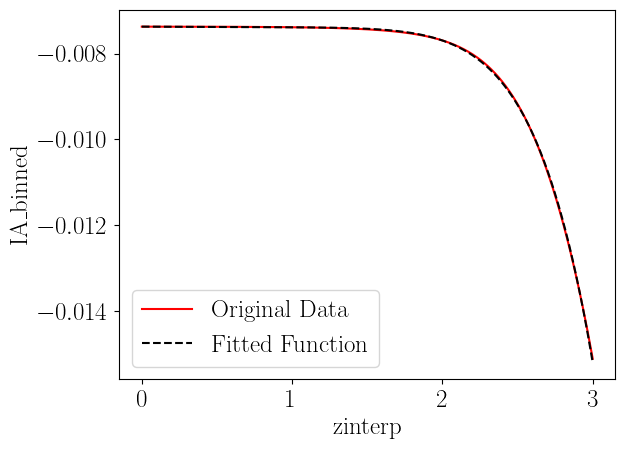

Chi-square: 1.532383324562696e-07
Function : -1.0997903864127544e-06x^ 8.069328178097443+exp( -1.3226784676272397e-05x) + -1.0073723997608188


In [53]:
from scipy.optimize import curve_fit
def model_function(x,a,b,c,d):
    return a*x**b+np.exp(c*x)+d

initial_guesses= [1,1,1,1]
params, params_covariance = curve_fit(model_function, zinterp, IA, p0=initial_guesses)

# Print the fitted parameters


# Generate fitted values
IA_fitted = model_function(zinterp, *params)

# Plot original data and fitted function
plt.plot(zinterp, IA, '-', label='Original Data', color= 'red')
plt.plot(zinterp, IA_fitted, '--', label='Fitted Function', color= 'black')
plt.xlabel('zinterp')
plt.ylabel('IA_binned')
plt.legend()
plt.show()

residuals = IA - IA_fitted

# Calculate chi-square
chi2 = np.sum((residuals)**2)
print(f"Chi-square: {chi2}")

print(f"Function : {params[0]}x^ {params[1]}+exp( {params[2]}x) + {params[3]}")
